# Delta Lorentz
Model of Delta function and Lorentzian with intensities given by the Debye-Waller factor:

$ I
= K \exp \left( \frac{-\langle u^2 \rangle Q^2}{3} \right)[A_0 \delta(E) + A_1 L(E, \Gamma)]
$,

where $K$ is the scale factor, $\langle u^2 \rangle$ is the mean square displacement, $Q$ is
the scattering vector, $A_0$ and $A_1$ are the relative amplitudes of the delta function and
Lorentzian, respectively, with the constraint that $A_0+A_1=1$, and $L(E, \Gamma)$ is the
Lorentzian function with width $\Gamma$. $A_0$, $A_1$ and the width of the Lorentzian can be
the same at all $Q$ or be allowed to vary with $Q$.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import easydynamics.sample_model as sm

%matplotlib widget

In [2]:
Q = np.linspace(0.5, 2, 7)
energy = np.linspace(-2, 2, 501)
scale = 1.0
mean_u_squared = 0.5
A_0 = 0.01
lorentzian_width = 0.2

diffusion_model = sm.DeltaLorentz(
    scale=scale,
    mean_u_squared=mean_u_squared,
    A_0=A_0,
    lorentzian_width=lorentzian_width,
    allow_Q_variation={'A_0': True, 'lorentzian_width': True},
    Q=Q,
    lorentzian_name='Lorentzian',
    delta_name='Delta function',
)

Both `A_0` and `lorentzian_width` are here allowed to vary with Q. We here change a few of them just to show how this impacts the model. The `# noqa` comment is because we are accessing private members of the model (ones beginning with `_`), which is generally discouraged. Because of these changes, in the figure below, the delta function at Q=1.25 Å^-1 is much larger than the other ones, and the Lorentzian at Q=1.75 Å^-1 is much narrower and taller than the other ones.

In [3]:
diffusion_model._A_0_list[3].value = 0.02  # noqa
diffusion_model._lorentzian_width_list[5].value = 0.1  # noqa

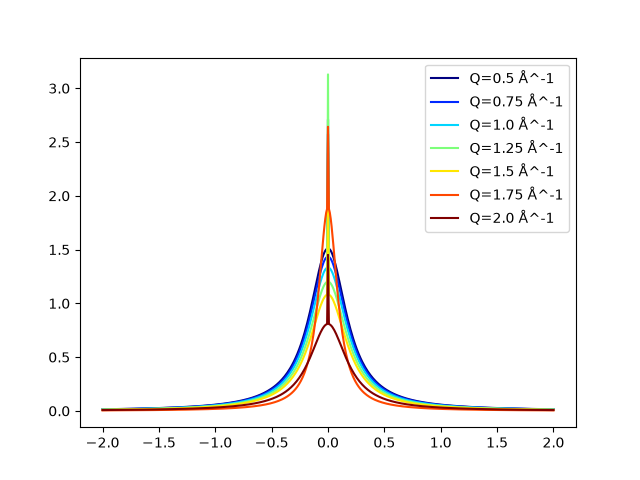

Text(0.5, 1.0, 'Delta-Lorentz Model')

In [4]:
component_collections = diffusion_model.get_component_collections()
cmap = plt.cm.jet
nQ = len(component_collections)
plt.figure()
for Q_index in range(len(component_collections)):
    color = cmap(Q_index / (nQ - 1))
    y = component_collections[Q_index].evaluate(energy)
    plt.plot(energy, y, label=f'Q={Q[Q_index]} Å^-1', color=color)

plt.legend()
plt.show()
plt.xlabel('Energy (meV)')
plt.ylabel('Intensity (arb. units)')
plt.title('Delta-Lorentz Model')

In [5]:
diffusion_model.get_all_variables()

[<Parameter 'scale': 1.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'mean_u_squared': 0.5000 Å^2, bounds=[0.0:inf]>,
 <Parameter 'A_0': 0.0100, bounds=[0.0:1.0]>,
 <Parameter 'A_0': 0.0100, bounds=[0.0:1.0]>,
 <Parameter 'A_0': 0.0100, bounds=[0.0:1.0]>,
 <Parameter 'A_0': 0.0200, bounds=[0.0:1.0]>,
 <Parameter 'A_0': 0.0100, bounds=[0.0:1.0]>,
 <Parameter 'A_0': 0.0100, bounds=[0.0:1.0]>,
 <Parameter 'A_0': 0.0100, bounds=[0.0:1.0]>,
 <Parameter 'A_1': 0.9900, bounds=[0.0:1.0]>,
 <Parameter 'A_1': 0.9900, bounds=[0.0:1.0]>,
 <Parameter 'A_1': 0.9900, bounds=[0.0:1.0]>,
 <Parameter 'A_1': 0.9800, bounds=[0.0:1.0]>,
 <Parameter 'A_1': 0.9900, bounds=[0.0:1.0]>,
 <Parameter 'A_1': 0.9900, bounds=[0.0:1.0]>,
 <Parameter 'A_1': 0.9900, bounds=[0.0:1.0]>,
 <Parameter 'Lorentzian area': 0.9496 meV, bounds=[0.0:inf]>,
 <Parameter 'Lorentzian center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Lorentzian width': 0.2000 meV, bounds=[1e-10:inf]>,
 <Parameter 'Delta function area': 0.0096 m